In [4]:
# interactive trajectory intercept minimizer

import matplotlib.pyplot as plt
from IPython.display import clear_output
from ipywidgets import interact, IntSlider, FloatSlider, Layout, interactive, Button, HTML, Checkbox
import numpy as np
from orbitengine.body import Body
import orbitengine.engine as oe
import astropy.units as u
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
import time

import orbitengine.utils as util
import time


width = '500px'
target_offset_angle_slider = FloatSlider(min=-.5, max=.1, value=0.01,step=0.01, layout=Layout(width=width), description='Target offset Earth angle')
thrust_angle_slider = FloatSlider(min=0, max=np.pi, value=2.00,step=0.01, layout=Layout(width=width), description='Thrust angle')
mass_slider = FloatSlider(min=10, max=10000, step=1, value=5000, layout=Layout(width=width), description='Mass')
radius_slider = FloatSlider(min=0.001, max=2, step=.001, value=1, layout=Layout(width=width), description='Radius')
t_flight_slider = IntSlider(min=10, max=500,value=189, layout=Layout(width=width), description='Flight time - Guess')
velocity_slider = FloatSlider(min=0, max=5, step=0.01, value=2.12, layout=Layout(width=width), description='Velocity - Guess')
style_html = HTML('<style>' + open('notebook_darkmode.css').read() + '</style>')

# Create the checkbox
drag_checkbox = Checkbox(value=False, description='Enable Atmospheric Drag')
temp_checkbox = Checkbox(value=False, description='Enable Radiant Temp')


def target_dist(x, thrust_angle, state_init, state_target, acc_params=None):
    velocity, t_flight = x
    v = util.spherical_to_cartesian(np.array([velocity, np.pi/2, thrust_angle]))*u.km/u.s
    
    state_maneuver = Body.State(state_init.position, 
                                v,
                                state_init.mass)

    sm = state_maneuver.propagate(oe.EARTH_K, t_flight*u.s, acc_params=acc_params)
    st = state_target.propagate(oe.EARTH_K, t_flight*u.s)

    dp = np.linalg.norm(st.position - sm.position).value
    return dp


def intercept_calc(target_offset_earth_angle, 
      thrust_angle, 
      t_flight, 
      velocity, 
      mass, 
      radius,
      enable_drag, 
      enable_temp):

    # Define a function that creates a plot
    state_init = Body.State(
    np.array([0,oe.EARTH_RADIUS_KM, 0])*u.km, 
    oe.V_ZERO, 
    mass*u.kg, 
    parent_axis_angle=oe.EARTH_AXIS_ANGLE_Z)

    # compute inital target position based on the offset angle
    rot_target = R.from_euler('z', target_offset_earth_angle)
    state_target = Body.State(rot_target.apply(state_init.position)*u.km, 
                              oe.V_ZERO, 
                              mass*u.kg,
                              parent_axis_angle=oe.EARTH_AXIS_ANGLE_Z)

    x0 = [velocity, t_flight]

    acc_params = oe.AccParams(
        axial_cross_section=np.pi*(radius*u.m)**2,
        atmosphere_axial_drag_coefficient=0.3,
        enable_drag=enable_drag)

    bounds = [(0, 100), (1, 5000)]


    res = util.minimize_cached(
                target_dist,
                x0, 
                cache_tol=1e-2,
                bounds=bounds,
                args=(thrust_angle, 
                        state_init, 
                        state_target, 
                        acc_params))

    util.print(f"postOptimization Err: {res.fun*u.km:.3f}")

    # guess maneuver
    v = util.spherical_to_cartesian(np.array([velocity, np.pi/2, thrust_angle]))*u.km/u.s
    state_guess_maneuver = Body.State(state_init.position, 
                                      v,
                                      state_init.mass)

    ts1 = np.linspace(0, t_flight*u.s, 100)
    sgm = state_guess_maneuver.propagate(oe.EARTH_K, ts1, acc_params=acc_params)
    st_guess = state_target.propagate(oe.EARTH_K, t_flight*u.s)

    plt.style.use('dark_background')
    fig, axs = plt.subplots(1, 1, figsize=(5, 5))

    # plot original inital guess maneuver trajectory
    axs.plot([s.position[0].value for s in sgm], [s.position[1].value for s in sgm], color='b')
    axs.plot(sgm[-1].position[0].value, sgm[-1].position[1].value, 'bo')
    axs.plot(st_guess.position[0].value, st_guess.position[1].value, 'ro',
              markerfacecolor='none', markeredgecolor='r', markersize=10)

    # optimized maneuver
    velocity, t_flight = res.x
    util.print(f"Optimized t_flight: {t_flight*u.s:.2f}")
    util.print(f"Optimized velocity: {velocity*u.km/u.s:.2f}")
    v = util.spherical_to_cartesian(np.array([velocity, np.pi/2, thrust_angle]))*u.km/u.s
    state_optimized_maneuver = Body.State(state_init.position,
                                           v,
                                           state_init.mass, 
                                           T=oe.TEMP_EARTH)

    #plot optimized trajectory
    ts2 = np.linspace(0, t_flight*u.s, 100)
    acc_params.enable_temp = enable_temp
    sm2 = state_optimized_maneuver.propagate(oe.EARTH_K, ts2, acc_params=acc_params)
    axs.plot([s.position[0].value for s in sm2], [s.position[1].value for s in sm2],color='g')
    axs.plot(sm2[-1].position[0].value, sm2[-1].position[1].value, 'go')

    st_final = state_target.propagate(oe.EARTH_K, t_flight*u.s)
    axs.plot(st_final.position[0].value, st_final.position[1].value, 'ro')


    axs.add_artist(plt.Line2D((0, st_final.position[0].value), (0, st_final.position[1].value), color='r', linestyle='dotted'))
    axs.plot(state_init.position[0].value, state_init.position[1].value, 'go')
 
    circle = plt.Circle((0, 0), oe.EARTH_RADIUS_KM, color='b', fill=False, linestyle='dotted')
    axs.add_artist(circle)
    axs.add_artist(plt.Line2D((0, state_init.position[0].value), (0, state_init.position[1].value), color='g', linestyle='dotted'))
    axs.set_aspect('equal', adjustable='box')
    plt.title('Trajectory Intercept')
    plt.show()


    plt.plot(ts2, [s.temperature.value for s in sm2])
    plt.ylabel('Temp (k)')
    plt.xlabel('Time (s)')
    plt.show()



# Define a function to be run when the button is clicked
def on_button_clicked(b):

    clear_output(wait=True)
    display(style_html,
            drag_checkbox,
            temp_checkbox,
            target_offset_angle_slider,
            thrust_angle_slider, 
            mass_slider, 
            radius_slider,
            t_flight_slider, 
            velocity_slider, 
            button)
    

    # Get the current values of the sliders
    target_angle = target_offset_angle_slider.value
    thrust_angle = thrust_angle_slider.value
    t_flight = t_flight_slider.value
    velocity = velocity_slider.value
    mass = mass_slider.value
    enable_drag = drag_checkbox.value
    enable_temp = temp_checkbox.value
    radius = radius_slider.value
    # Call your function with these values    
    intercept_calc(target_angle, 
                   thrust_angle, 
                   t_flight, 
                   velocity, 
                   mass, 
                   radius, 
                   enable_drag, 
                   enable_temp)

# Set this function to be called when the button is clicked
button = Button(description="Run")

button.on_click(on_button_clicked)

on_button_clicked(button)


ModuleNotFoundError: No module named 'panda3d.core'

0.870663650075414
0.0
[0.79374057 0.5        0.5        0.5        0.5        0.5
 0.5        0.5        0.         0.5        0.5        0.5
 0.5        0.5        0.5        0.5        0.21428571 0.5
 0.5        0.5        0.5        0.5        0.         0.5
 0.5        0.5        0.5        0.5        0.5        0.5
 0.55882353 0.5        0.5        0.5        0.5        0.5
 0.5        0.5        0.5        0.5        0.5        0.5
 0.5        0.5        0.5        0.5        0.5        0.5
 0.43419165 0.5        0.5       ]


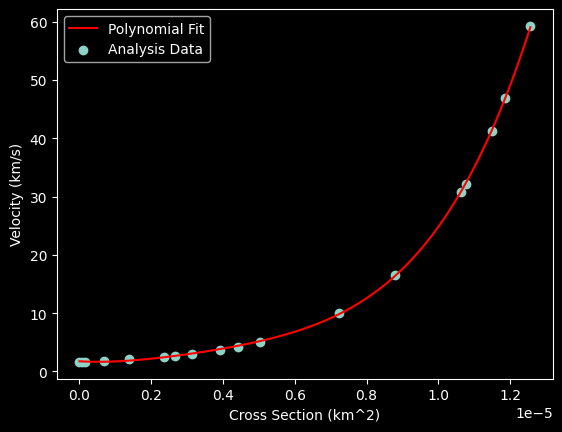

In [121]:
import os
import pickle
import os
import os
import pickle

from astropy.units import Quantity
def tolist(item):
    if isinstance(item, list):
        return [tolist(subitem) for subitem in item]
    elif isinstance(item, dict):
        return [tolist(value) for key, value in item.items()]
    elif isinstance(item, tuple):  # Handle tuples
        return list(tolist(subitem) for subitem in item)
    elif isinstance(item, Quantity):
            return item.value.tolist()
    elif isinstance(item, np.ndarray):
        return item.tolist()
    elif isinstance(item, object) and hasattr(item, '__dict__'):
       return tolist(item.__dict__)
    elif isinstance(item, bool):
        return 1 if item else 0
    elif item is None:
        return 0
    else:
        return item

def flatten(lst):
    return [item for sublist in lst for item in flatten(sublist)] if isinstance(lst, list) else [lst]

#list file in dir
file_list = os.listdir(util.CACHE_DIR)
data = []
input_tensor = []
output_tensor = []
for file in file_list:
    if file.startswith('__main__target_dist'):
        with open(os.path.join(dir, file), 'rb') as fp:
            info = pickle.load(fp)
            accParms = info['kwargs']['args'][3]
            args = info['kwargs']['args']
            res = info['res']
            output_tensor.append(flatten(tolist(res.x)))
            input_tensor.append(flatten(tolist(args)))
            if not accParms.enable_drag:
                continue
            thrust_angle = info['kwargs']['args'][0]
            if thrust_angle == 2:
                data.append([res.x[0], 
                            accParms.axial_cross_section])


input_tensor = np.array(input_tensor)
input_mean_tensor = np.mean(input_tensor, axis=0)
input_tensor = (input_tensor-input_mean_tensor)
#print(np.mean(args_tensor,axis=0))
input_scale_tensor = np.max(input_tensor,axis=0)-np.min(input_tensor,axis=0)
input_scale_tensor[input_scale_tensor == 0] = 1
input_tensor/=2*input_scale_tensor  # why?
input_tensor += 0.5

print(np.max(input_tensor))
print(np.min(input_tensor))
print(input_tensor[0])

data = np.array(data)
# Fit a polynomial to the analysis data
coefficients = np.polyfit(data[:, 1], data[:, 0], deg=4)

# Generate x values for the polynomial curve
x_values = np.linspace(min(data[:, 1]), max(data[:, 1]), 100)

# Evaluate the polynomial at the x values
y_values = np.polyval(coefficients, x_values)

# Plot the polynomial curve
plt.plot(x_values, y_values, color='r', label='Polynomial Fit')
plt.scatter(data[:, 1], data[:, 0], label='Analysis Data')
plt.xlabel("Cross Section (km^2)")
plt.ylabel("Velocity (km/s)")
plt.legend()
plt.show()


In [2]:
import faiss
import numpy as np

import os
import pickle

from astropy.units import Quantity
def tolist(item):
    if isinstance(item, list):
        return [tolist(subitem) for subitem in item]
    elif isinstance(item, dict):
        return [tolist(value) for key, value in item.items()]
    elif isinstance(item, tuple):  # Handle tuples
        return list(tolist(subitem) for subitem in item)
    elif isinstance(item, Quantity):
            return item.value.tolist()
    elif isinstance(item, np.ndarray):
        return item.tolist()
    elif isinstance(item, object) and hasattr(item, '__dict__'):
       return tolist(item.__dict__)
    elif isinstance(item, bool):
        return 1 if item else 0
    elif item is None:
        return 0
    else:
        return item

def flatten(lst):
    return [item for sublist in lst for item in flatten(sublist)] if isinstance(lst, list) else [lst]


def extract_features(file_path):
    with open(file_path, 'rb') as fp:
        info = pickle.load(fp)
        args = info['kwargs']['args']
        feature_vector = np.array(flatten(tolist(args)))
        return feature_vector.astype('float32')  

# File list
file_paths = ["image1.jpg", "document.txt", "audio.wav", ...]  

#list file in dir
file_list = os.listdir(util.CACHE_DIR)
file_paths = [os.path.join(util.CACHE_DIR, file) for file in file_list]


# Feature Extraction
features = []
for file_path in file_paths:
    feature_vector = extract_features(file_path)
    print(feature_vector)
    features.append(feature_vector)

data = np.stack(features)  # Combine vectors into a NumPy array

# Build Faiss Index
dimension = data.shape[1]  
index = faiss.IndexFlatL2(dimension) 
index.add(data) 

# Searching (Example)
query_file = "new_image.jpg"
query_vector = extract_features(query_file).astype('float32')
k = 10  # Find the 10 most similar files
distances, indices = index.search(np.array([query_vector]), k)

# Results
for i in indices[0]:  
    print(file_paths[i])  # Print paths of similar files


Nearest neighbors IDs:
 [ 6020 71060 68944 68568 21229]
Distances to query:
 [68.65344 68.67982 68.78435 68.86431 68.90431]
